### Assignment-03

- Using the provided ```U-Net``` training notebook as a reference, develop and train a ```DeepLabv3+``` model on the sample dataset available in the ```data``` folder (accessible through the provided Google Drive shortcut).

- For model evaluation, use the same test image that was previously used to evaluate the U-Net model. Save and upload the output image generated by your trained DeepLabv3+ model to the ```data/output``` folder.

In [3]:
import tensorflow as tf
import keras_cv
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt



In [4]:
keras_cv.models.DeepLabV3Plus


keras_cv.src.models.segmentation.deeplab_v3_plus.deeplab_v3_plus.DeepLabV3Plus

In [ ]:
import tensorflow as tf
import keras_cv
from tensorflow import keras
backbone = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)


In [ ]:
import keras_cv
backbone = keras_cv.models.ResNet50Backbone(
    include_rescaling=True
)


100%|██████████| 761/761 [00:00<00:00, 2.24MB/s]


In [ ]:
model = keras_cv.models.DeepLabV3Plus(
    backbone=backbone,
    num_classes=1,
    activation="sigmoid"
)


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
!ls /content/drive/MyDrive


 ai_vision_extract			     resume.pdf
 COCO2017_SAMPLE			     Untitled0.ipynb
'Colab Notebooks'			     Untitled1.ipynb
'Completion Certificate _ SkillsBuild.PDF'


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ai_vision_extract/milestone_3/week1/archive/images"
IMG_SIZE = 256


In [ ]:
import os

files = os.listdir(BASE_PATH)

print("First 10 files in images folder:\n")
for f in files[:10]:
    print(f)

print("\nFirst mask file:\n")
for f in files:
    if "__save" in f:
        print(f)
        break


First 10 files in images folder:

Frame 1  (100).jpg___save.png
Frame 1  (1).jpg___save.png
Frame 1  (10).jpg___fuse.png
Frame 1  (100).jpg___fuse.png
Frame 1  (1).jpg___fuse.png
Frame 1  (10).jpg___save.png
Frame 1  (2).jpg___fuse.png
Frame 1  (11).jpg___save.png
Frame 1  (2).jpg___save.png
Frame 1  (17).jpg

First mask file:

Frame 1  (100).jpg___save.png


In [ ]:
for f in files:
    if "__save" in f:
        print("Mask file :", f)
        derived = f.replace("__save.png", "")
        print("Derived img:", derived)
        print("Exists?    :", os.path.exists(os.path.join(BASE_PATH, derived)))
        break


Mask file : Frame 1  (100).jpg___save.png
Derived img: Frame 1  (100).jpg_
Exists?    : False


In [ ]:
import os
import cv2
import numpy as np

def load_data(base_path, img_size=256):
    images = []
    masks = []

    files = os.listdir(base_path)

    # Mask files have ___save.png
    mask_files = [f for f in files if f.endswith("___save.png")]

    print("Total mask files found:", len(mask_files))

    for mask_name in mask_files:
        # Correctly derive original image name
        img_name = mask_name.replace("___save.png", "")

        img_path = os.path.join(base_path, img_name)
        mask_path = os.path.join(base_path, mask_name)

        if not os.path.exists(img_path):
            continue

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0

        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size, img_size))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)


In [ ]:
X, y = load_data(BASE_PATH, IMG_SIZE)

print("Images shape:", X.shape)
print("Masks shape :", y.shape)


Total mask files found: 100
Images shape: (100, 256, 256, 3)
Masks shape : (100, 256, 256, 1)


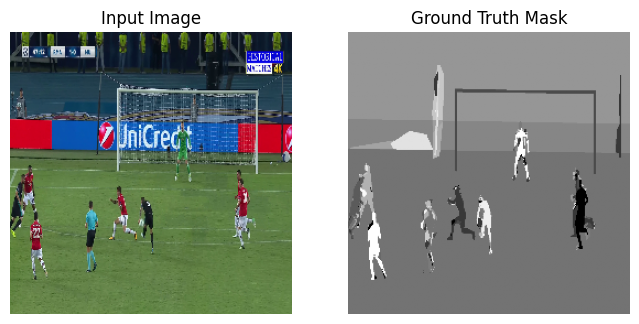

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X[0])
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(y[0].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train images:", X_train.shape)
print("Val images  :", X_val.shape)


Train images: (80, 256, 256, 3)
Val images  : (20, 256, 256, 3)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,        # assignment ki enough
    batch_size=4
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4, 256, 256, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 387ms/step - accuracy: 0.0000e+00 - loss: 0.5750 - val_accuracy: 0.0000e+00 - val_loss: 0.6315
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.0000e+00 - loss: 0.4926 - val_accuracy: 0.0000e+00 - val_loss: 0.5544
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.0000e+00 - loss: 0.4902 - val_accuracy: 0.0000e+00 - val_loss: 0.5269
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.0000e+00 - loss: 0.4924 - val_accuracy: 0.0000e+00 - val_loss: 0.5141
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.0000e+00 - loss: 0.4881 - val_accuracy: 0.0000e+00 - val_loss: 0.4846


In [ ]:
test_image = X_val[0]

prediction = model.predict(
    np.expand_dims(test_image, axis=0)
)[0]

pred_mask = (prediction > 0.5).astype("uint8")


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 256, 256, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
import os
import cv2

output_dir = "/content/drive/MyDrive/Infosys/ai_vision_extract/milestone_3/week1/archive/output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "deeplabv3plus_output.png")

cv2.imwrite(output_path, pred_mask * 255)

print("✅ Output saved at:", output_path)


✅ Output saved at: /content/drive/MyDrive/Infosys/ai_vision_extract/milestone_3/week1/archive/output/deeplabv3plus_output.png


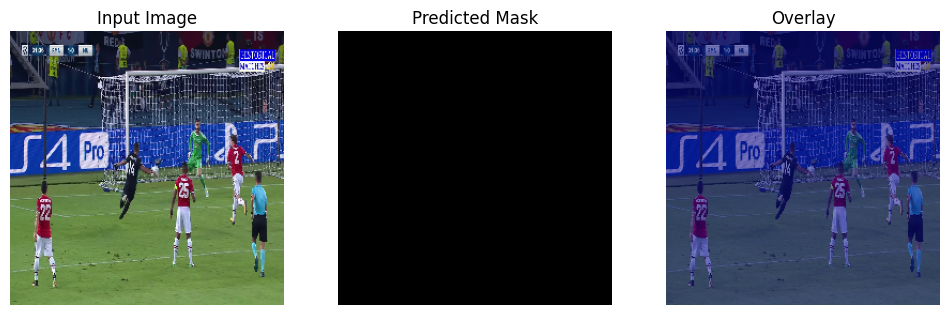

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(test_image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(test_image)
plt.imshow(pred_mask.squeeze(), alpha=0.5, cmap="jet")
plt.axis("off")

plt.show()
